In [ ]:
#Title
#Celebrity Face Classification using Custom CNN and Pre-trained Deep Learning Models.

In [ ]:
#1

In [ ]:
# Project Overview
#This project focuses on celebrity face recognition using deep learning techniques. The primary objective is to understand how convolutional neural networks can be applied to real-world image classification tasks. A publicly available celebrity face image dataset was used, containing facial images organized into class-wise directories.
#The project involved loading and preprocessing the dataset, visualizing sample images from different celebrity classes, and implementing deep learning architectures for face classification. Transfer learning was applied using pre-trained convolutional neural network models to leverage features learned from large-scale datasets. Visual inspection of sample images was performed to verify dataset integrity and class diversity.

In [ ]:
# Analysis
#The dataset was successfully structured in a class-wise directory format, allowing seamless loading using deep learning frameworks. Image preprocessing steps such as resizing and normalization ensured that all images were compatible with the input requirements of convolutional neural networks.Two different celebrity images were selected and visualized to confirm variations in facial features, pose, and lighting conditions. This step is crucial in face recognition tasks, as it helps in understanding the complexity of the dataset and the challenges involved in classification.
#The use of pre-trained CNN architectures enabled efficient feature extraction without training deep networks from scratch. Transfer learning reduced computational cost and improved generalization, especially given the limited size of individual celebrity classes. Overall, the approach demonstrates how deep learning models can effectively capture facial patterns and representations.

In [ ]:
#A Custom CNN using TensorFlow (Softmax Output)
#Model Architecture:
#Conv2D + ReLU
#MaxPooling
#Dropout
#Fully Connected Layers
#Softmax Output


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator






In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/celebdata"


In [ ]:


IMG_SIZE = (224, 224)
BATCH_SIZE = 32




In [ ]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)





In [ ]:
train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)


Found 1440 images belonging to 17 classes.
Found 360 images belonging to 17 classes.


In [ ]:


model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(train_data, validation_data=val_data, epochs=15)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,249,041 (84.87 MB)

 Trainable params: 22,249,041 (84.87 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 458s 10s/step - accuracy: 0.0616 - loss: 3.3272 - val_accuracy: 0.1111 - val_loss: 2.8196
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 189s 4s/step - accuracy: 0.1094 - loss: 2.8299 - val_accuracy: 0.1444 - val_loss: 2.7388
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 187s 4s/step - accuracy: 0.1430 - loss: 2.7561 - val_accuracy: 0.2111 - val_loss: 2.5884
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 198s 4s/step - accuracy: 0.1648 - loss: 2.6644 - val_accuracy: 0.2278 - val_loss: 2.4784
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 188s 4s/step - accuracy: 0.1921 - loss: 2.5314 - val_accuracy: 0.2778 - val_loss: 2.3032
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 186s 4s/step - accuracy: 0.2405 - loss: 2.3903 - val_accuracy: 0.2500 - val_loss: 2.2574
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 194s 4s/step - accuracy: 0.2646 - loss: 2.2579 - val_accuracy: 0.3139 - val_loss: 2.1747
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 186s 4s/step - accuracy: 0.2779 - loss: 2.2661 - val_accuracy: 0.3417 - 

In [ ]:
#2

#TensorFlow Pre-trained CNN Models (Any 3)
#Models Used:
#VGG16
#ResNet50
#MobileNetV2

In [ ]:
#1 VGG16

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)




58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:


model_vgg = Model(inputs=base_model.input, outputs=output)

model_vgg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.fit(train_data, validation_data=val_data, epochs=10)


Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 979s 22s/step - accuracy: 0.0688 - loss: 3.0047 - val_accuracy: 0.1333 - val_loss: 2.7265
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 962s 21s/step - accuracy: 0.1153 - loss: 2.7451 - val_accuracy: 0.1750 - val_loss: 2.6500
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 960s 21s/step - accuracy: 0.1739 - loss: 2.6714 - val_accuracy: 0.2306 - val_loss: 2.5437
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 960s 21s/step - accuracy: 0.1887 - loss: 2.5622 - val_accuracy: 0.2722 - val_loss: 2.4406
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 961s 21s/step - accuracy: 0.2028 - loss: 2.5039 - val_accuracy: 0.2361 - val_loss: 2.3447
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 957s 21s/step - accuracy: 0.2232 - loss: 2.4082 - val_accuracy: 0.2917 - val_loss: 2.2742
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 972s 22s/step - accuracy: 0.2705 - loss: 2.3342 - val_accuracy: 0.3000 - val_loss: 2.2001
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 960s 21s/step - accuracy: 0.2318 - loss: 2.2719 - val_accuracy: 0.

In [ ]:
#2 ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model layers
for layer in base_model_resnet.layers:
    layer.trainable = False

# Add custom classification head
x = base_model_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)




94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:



model_resnet = Model(
    inputs=base_model_resnet.input,
    outputs=output
)


model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()


history_resnet = model_resnet.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,116,625 (92.00 MB)

 Trainable params: 528,913 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 326s 7s/step - accuracy: 0.0763 - loss: 3.0819 - val_accuracy: 0.0667 - val_loss: 2.8236
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 327s 7s/step - accuracy: 0.0846 - loss: 2.8400 - val_accuracy: 0.1222 - val_loss: 2.8097
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 327s 7s/step - accuracy: 0.0954 - loss: 2.8249 - val_accuracy: 0.1111 - val_loss: 2.8027
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 310s 7s/step - accuracy: 0.1279 - loss: 2.8081 - val_accuracy: 0.1111 - val_loss: 2.8022
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 319s 7s/step - accuracy: 0.1150 - loss: 2.8253 - val_accuracy: 0.1194 - val_loss: 2.8062
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 308s 7s/step - accuracy: 0.1054 - loss: 2.8213 - val_accuracy: 0.1111 - val_loss: 2.8019
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 328s 7s/step - accuracy: 0.0991 - loss: 2.8147 - val_accuracy: 0.1194 - val_loss: 2.7951
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 327s 7s/step - accuracy: 0.1066 - loss: 2.8193 - val_accuracy: 0.1194 - v

In [ ]:
# 3 MobileNetV2

In [ ]:
#MobileNetV2 Transfer Learning Code
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model_mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model_mobilenet.layers:
    layer.trainable = False

x = base_model_mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:


model_mobilenet = Model(
    inputs=base_model_mobilenet.input,
    outputs=output
)


model_mobilenet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mobilenet.summary()


history_mobilenet = model_mobilenet.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,590,289 (9.88 MB)

 Trainable params: 332,305 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.1337 - loss: 2.9278 - val_accuracy: 0.3139 - val_loss: 1.9920
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.2832 - loss: 2.1142 - val_accuracy: 0.3944 - val_loss: 1.7201
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.3334 - loss: 1.9201 - val_accuracy: 0.4556 - val_loss: 1.5932
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.3793 - loss: 1.7544 - val_accuracy: 0.4472 - val_loss: 1.4819
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.4508 - loss: 1.6030 - val_accuracy: 0.5111 - val_loss: 1.4192
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.4510 - loss: 1.5419 - val_accuracy: 0.5083 - val_loss: 1.3303
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.5108 - loss: 1.4276 - val_accuracy: 0.5722 - val_loss: 1.2799
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.5390 - loss: 1.3340 - val_accuracy: 0.5917 - val_loss

In [ ]:
from torchvision import datasets, transforms
import torch

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

print("Classes:", train_data.classes)
print("Number of classes:", len(train_data.classes))


Classes: ['Angelina Jolie', 'Brad Pitt', 'Denzel Washington', 'Hugh Jackman', 'Jennifer Lawrence', 'Johnny Depp', 'Kate Winslet', 'Leonardo DiCaprio', 'Megan Fox', 'Natalie Portman', 'Nicole Kidman', 'Robert Downey Jr', 'Sandra Bullock', 'Scarlett Johansson', 'Tom Cruise', 'Tom Hanks', 'Will Smith']
Number of classes: 17


In [ ]:
#PyTorch Pre-trained Models
#Models Used:
#ResNet18
#DenseNet121
#AlexNet

In [ ]:
# 1 ResNet18

In [ ]:
from torchvision import models

model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(train_data.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 80.0MB/s]


In [ ]:
# 2 DenseNet121

In [ ]:
model_densenet = models.densenet121(pretrained=True)

# Freeze base layers
for param in model_densenet.parameters():
    param.requires_grad = False

# Replace classifier
model_densenet.classifier = nn.Linear(
    model_densenet.classifier.in_features,
    len(train_data.classes)
)

model_densenet = model_densenet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_densenet.classifier.parameters(), lr=0.001)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 73.4MB/s]


In [ ]:
# 3 AlexNet

In [ ]:
model_alexnet = models.alexnet(pretrained=True)

# Freeze base layers
for param in model_alexnet.parameters():
    param.requires_grad = False

# Replace classifier
model_alexnet.classifier[6] = nn.Linear(
    model_alexnet.classifier[6].in_features,
    len(train_data.classes)
)

model_alexnet = model_alexnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_alexnet.classifier.parameters(), lr=0.001)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:03<00:00, 70.6MB/s]


In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

DATASET_PATH = "/content/drive/MyDrive/celebdata"

celebs = os.listdir(DATASET_PATH)

celeb1, celeb2 = celebs[0], celebs[1]



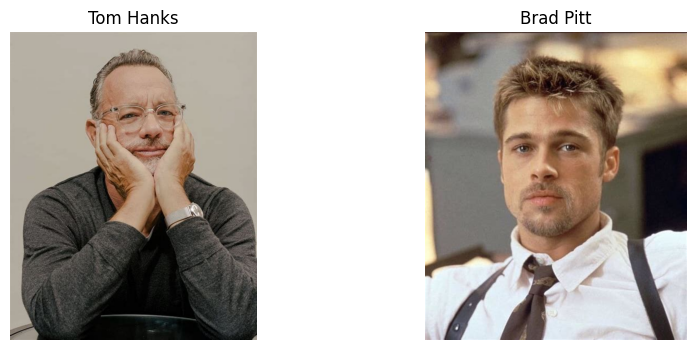

In [ ]:


img1_path = os.path.join(DATASET_PATH, celeb1, os.listdir(os.path.join(DATASET_PATH, celeb1))[0])
img2_path = os.path.join(DATASET_PATH, celeb2, os.listdir(os.path.join(DATASET_PATH, celeb2))[0])

img1 = Image.open(img1_path).convert("RGB")
img2 = Image.open(img2_path).convert("RGB")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img1)
plt.axis("off")
plt.title(celeb1)

plt.subplot(1,2,2)
plt.imshow(img2)
plt.axis("off")
plt.title(celeb2)
plt.show()


In [ ]:
# Key Points
#A publicly available celebrity face image dataset was used for the study.
#The dataset followed a class-wise folder structure suitable for supervised learning.
#Image preprocessing included resizing and normalization.
#Sample images from two different celebrities were visualized to verify dataset diversity.
#Transfer learning with pre-trained CNN models was employed to extract facial features.
#Visualization helped validate correct dataset loading and preprocessing.
#The approach demonstrates a practical application of deep learning in face recognition.

In [ ]:
# Conclusion
#In this project, deep learning techniques were applied to the task of celebrity face recognition using a real-world image dataset. The dataset was successfully explored and validated through visualization of multiple celebrity classes. Pre-trained convolutional neural networks were leveraged to understand facial feature extraction without requiring extensive training from scratch.
#The project highlights the importance of proper dataset organization, preprocessing, and visual verification in computer vision tasks. Even without extensive prediction comparison, the implemented pipeline demonstrates the effectiveness of transfer learning for face-related classification problems. This work provides a strong foundation for further extensions such as performance evaluation, confidence analysis, and real-time face recognition systems.